In [1]:
from facenet_pytorch import InceptionResnetV1
import PIL
from torchvision import transforms
from matplotlib import pyplot as plt
import torch
import yaml
import faiss
from tqdm import tqdm
import numpy as np
import os
from torch.utils.data import DataLoader,Dataset

option_path='config.yaml'
with open(option_path,'r') as file_option:
    files_option=yaml.safe_load(file_option)

/home/artemybombastic/Git/ZekNet/embedder_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#проверочка что нахожусь в нужно окружении
# import sys
# print(sys.executable)

In [3]:
# def img2tensor(img):
#     trans=transforms.Compose([
#         transforms.Resize((256,256)),
#         transforms.ToTensor()
#     ])
#     tensor=trans(img)
#     return tensor

In [4]:
class TestDataset(Dataset):
    def __init__(self,path):
        super().__init__()

        self.trans=transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor()
        ])

        self.images=[]
        for name in os.listdir(path):
            for filename in os.listdir(os.path.join(path,name)):
               self.images.append(os.path.join(os.path.join(path,name),filename))

    def __len__(self):
        return len(self.images)
    def __getitem__(self,idx):

        return self.trans(PIL.Image.open(self.images[idx]))
        

In [5]:
test_data=TestDataset(path=files_option['test_img_path'])

In [6]:
test_data[2]

tensor([[[0.7608, 0.7647, 0.7843,  ..., 0.6353, 0.5412, 0.4902],
         [0.7216, 0.7294, 0.7569,  ..., 0.5961, 0.5059, 0.4745],
         [0.6549, 0.6784, 0.7255,  ..., 0.5569, 0.4784, 0.4941],
         ...,
         [0.0078, 0.0078, 0.0078,  ..., 0.1451, 0.1333, 0.1333],
         [0.0157, 0.0078, 0.0078,  ..., 0.1294, 0.1333, 0.1451],
         [0.0902, 0.0039, 0.0078,  ..., 0.1137, 0.1451, 0.2157]],

        [[0.7490, 0.7529, 0.7647,  ..., 0.6157, 0.5294, 0.4863],
         [0.7098, 0.7176, 0.7412,  ..., 0.5725, 0.4941, 0.4706],
         [0.6431, 0.6667, 0.7098,  ..., 0.5333, 0.4667, 0.4902],
         ...,
         [0.0078, 0.0078, 0.0078,  ..., 0.1176, 0.1059, 0.1059],
         [0.0157, 0.0078, 0.0078,  ..., 0.0980, 0.1020, 0.1137],
         [0.0902, 0.0039, 0.0078,  ..., 0.0863, 0.1176, 0.1882]],

        [[0.7294, 0.7333, 0.7490,  ..., 0.6157, 0.5255, 0.4784],
         [0.6902, 0.6980, 0.7216,  ..., 0.5725, 0.4863, 0.4627],
         [0.6235, 0.6471, 0.6902,  ..., 0.5333, 0.4627, 0.

In [7]:
embeder=InceptionResnetV1(pretrained='vggface2').eval()

In [8]:
test_dataloader=DataLoader(dataset=test_data,batch_size=16,drop_last=False,shuffle=False)

In [9]:
embendings=np.array([])
for batch in tqdm(test_dataloader):
    pred=embeder(batch)
    embendings=np.append(embendings,pred.detach().numpy())
    #embendings=np.append(embendings,1)
    #break

100%|██████████████████████████████████████| 113/113 [01:27<00:00,  1.29it/s]


In [10]:
embendings=embendings.reshape(-1,512)

In [11]:
indexer=faiss.IndexFlatL2(512)
indexer.add(embendings)#добавляем базу

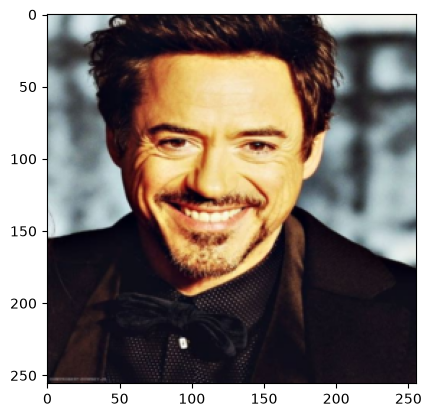

In [43]:
plt.imshow(test_data[735].permute(1,2,0))

In [38]:
similarities, indices=indexer.search(x=embendings[700].reshape(1,-1),k=3)

In [39]:
similarities

array([[0.        , 0.39334095, 0.41806066]], dtype=float32)

In [40]:
indices

array([[700, 735, 782]])

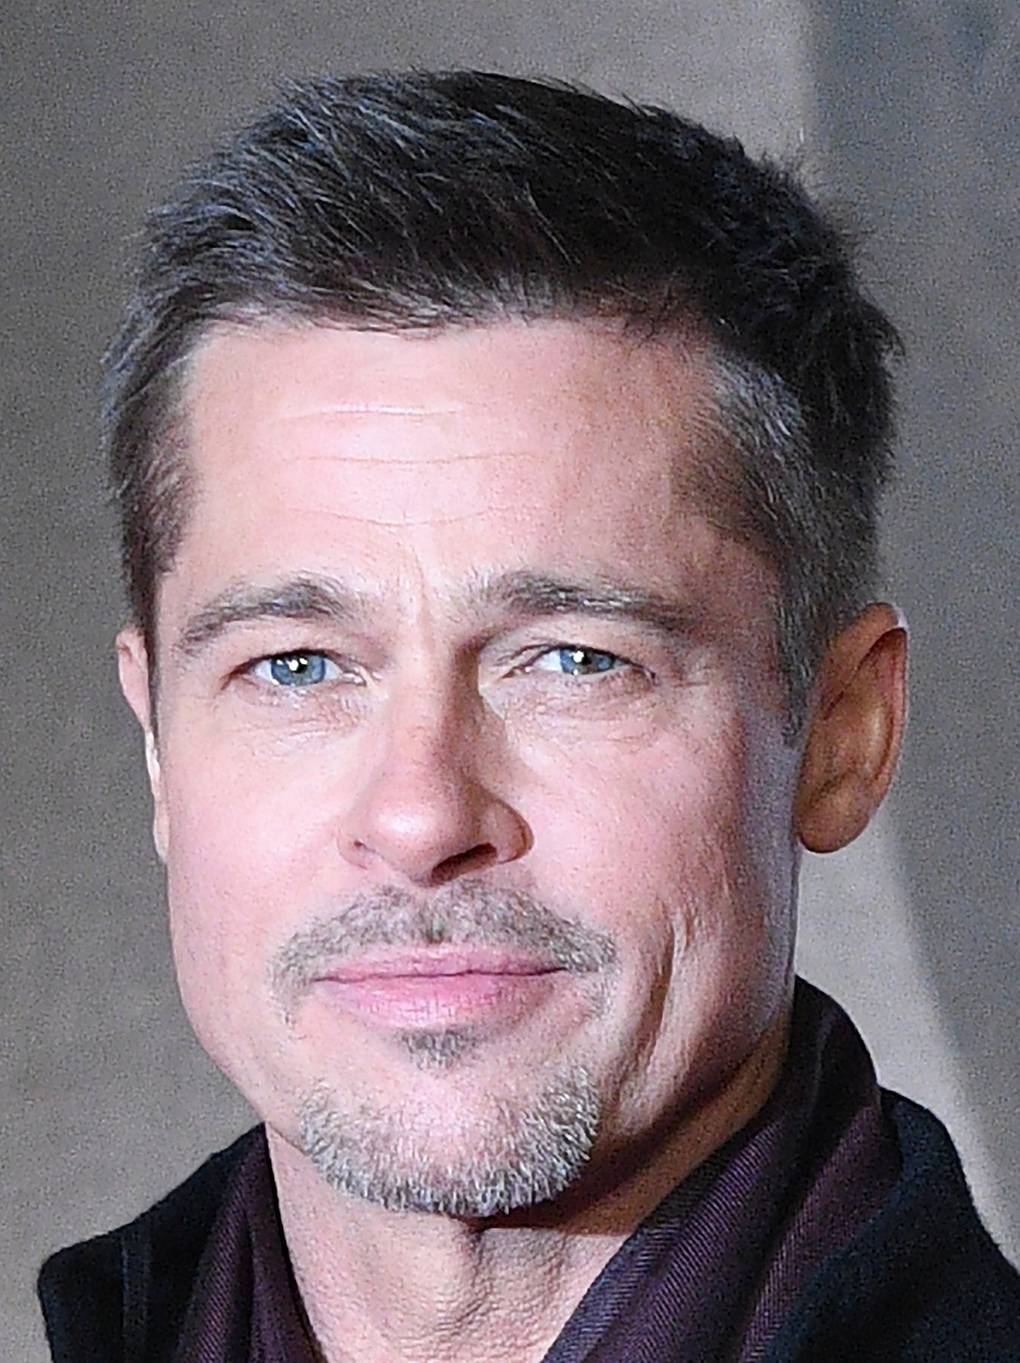

In [29]:
data[indices.item()]

In [1]:
1+1

2

In [37]:
import numpy as np

# Список из 20 массивов по 16 элементов
batches = [np.random.rand(16) for _ in range(20)]

# Новый массив (320,)
result = np.concatenate(batches)


In [40]:
len(batches)

20

In [41]:
result.shape

(320,)